In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from matplotlib.colors import LinearSegmentedColormap

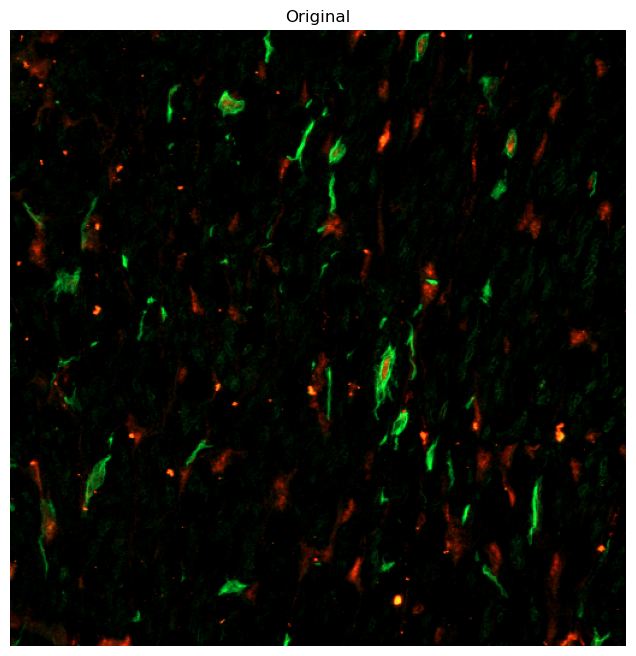


COLOCALIZATION RESULTS
IBA1 area = 4322
IL1β area = 15994
Colocalized area = 1216

% IBA1 containing IL1β = 28.14
% Total IL1β inside IBA1 = 7.6
% Total IL1β outside IBA1 = 92.4


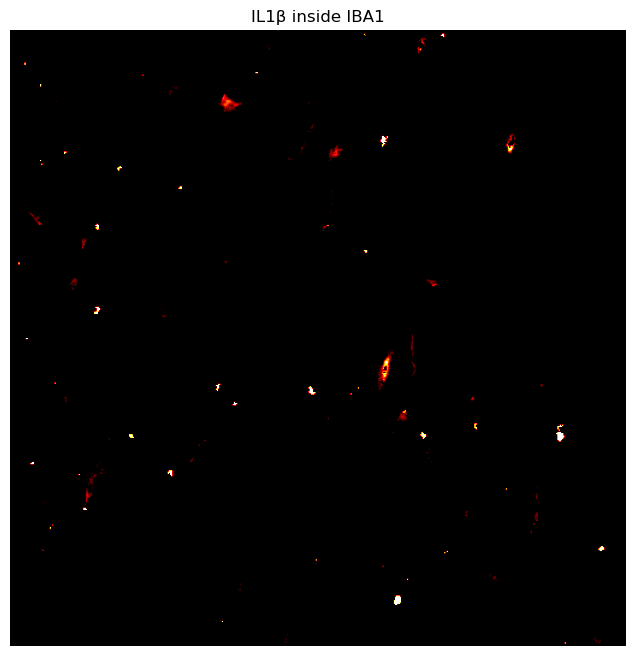

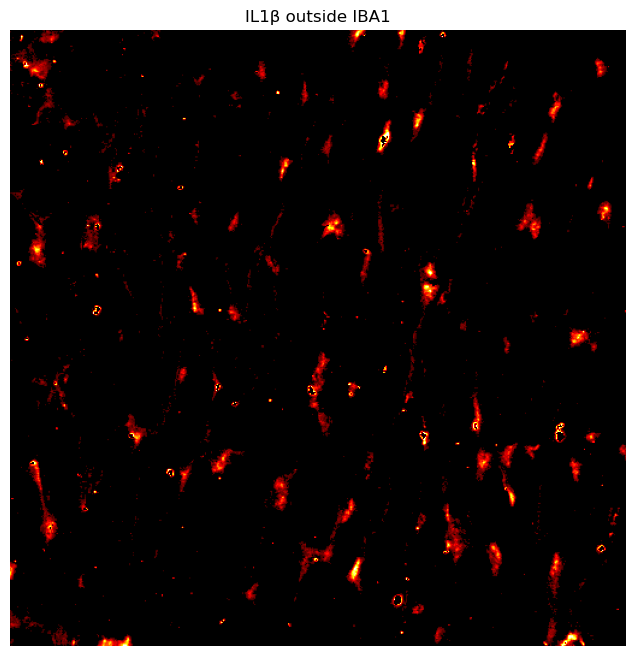

(4322, 15994, 1216, 28.135122628412773, 7.6028510691509315, 92.39714893084907)

In [52]:

# ============================================================
# COLORMAP PERSONALIZADO
# Negro -> Rojo -> Amarillo -> Blanco
# ============================================================

custom_heatmap = LinearSegmentedColormap.from_list(
    "custom_heatmap",
    [
        (0.0, (0.0, 0.0, 0.0)),   # Negro
        (0.4, (1.0, 0.0, 0.0)),   # Rojo
        (0.75, (1.0, 1.0, 0.0)),  # Amarillo
        (1.0, (1.0, 1.0, 1.0))    # Blanco
    ]
)

# ============================================================
# GUARDAR IMÁGENES SIN EJES
# ============================================================

def SaveImage(image, save_path, cmap=None):

    fig = plt.figure(frameon=False)

    fig.set_size_inches(
        image.shape[1] / 300,
        image.shape[0] / 300
    )

    ax = plt.Axes(fig, [0., 0., 1., 1.])

    ax.set_axis_off()

    fig.add_axes(ax)

    if cmap is None:
        ax.imshow(image)

    else:
        ax.imshow(image, cmap=cmap)

    fig.savefig(
        save_path,
        dpi=300,
        bbox_inches='tight',
        pad_inches=0
    )

    plt.close(fig)

# ============================================================
# MOSTRAR IMAGEN
# ============================================================

def ShowImage(image, title="", cmap=None):

    plt.figure(figsize=(8,8))

    if cmap is None:
        plt.imshow(image)

    else:
        plt.imshow(image, cmap=cmap)

    plt.title(title)

    plt.axis("off")

    plt.show()

# ============================================================
# COLOCALIZACIÓN
# ============================================================

def ColocalizationQuant(
    image,
    green_threshold,
    red_threshold,
    output_dir,
    filename
):

    green = image[:, :, 1]   # IBA1

    red = image[:, :, 0]     # IL1β

    # ----------------------------------------------------
    # Máscaras binarias
    # ----------------------------------------------------

    green_mask = green > green_threshold

    red_mask = red > red_threshold

    coloc_mask = green_mask & red_mask

    outside_mask = red_mask & (~green_mask)

    # ----------------------------------------------------
    # Cuantificación
    # ----------------------------------------------------

    green_area = np.sum(green_mask)

    red_area = np.sum(red_mask)

    coloc_area = np.sum(coloc_mask)

    outside_area = np.sum(outside_mask)


    # ----------------------------------------------------
    # Intensidad de IL1β en colocalización
    # ----------------------------------------------------
    coloc_intensity = red[coloc_mask]
    if coloc_intensity.size > 0:
        mean_intensity = np.mean(coloc_intensity)
        median_intensity = np.median(coloc_intensity)
        max_intensity = np.max(coloc_intensity)
        std_intensity = np.std(coloc_intensity)
        integrated_density = np.sum(coloc_intensity)
    else:
        mean_intensity = median_intensity = max_intensity = std_intensity = integrated_density = 0


    percent_microglia_positive = (
        coloc_area / green_area * 100
        if green_area > 0 else 0
    )

    percent_il1b_inside = (
        coloc_area / red_area * 100
        if red_area > 0 else 0
    )

    percent_il1b_outside = (
        outside_area / red_area * 100
        if red_area > 0 else 0
    )

    print()
    print("================================")
    print("COLOCALIZATION RESULTS")
    print("================================")
    print("IBA1 area =", green_area)
    print("IL1β area =", red_area)
    print("Colocalized area =", coloc_area)
    print()

    print(
        "% IBA1 containing IL1β =",
        round(percent_microglia_positive, 2)
    )

    print(
        "% Total IL1β inside IBA1 =",
        round(percent_il1b_inside, 2)
    )

    print(
        "% Total IL1β outside IBA1 =",
        round(percent_il1b_outside, 2)
    )

    print("================================")

    # ----------------------------------------------------
    # Guardar máscaras
    # ----------------------------------------------------

    SaveImage(
        green_mask.astype(np.uint8) * 255,
        os.path.join(
            output_dir,
            f"{filename}_IBA1_MASK.png"
        ),
        cmap="gray"
    )

    SaveImage(
        red_mask.astype(np.uint8) * 255,
        os.path.join(
            output_dir,
            f"{filename}_IL1B_MASK.png"
        ),
        cmap="gray"
    )

    SaveImage(
        coloc_mask.astype(np.uint8) * 255,
        os.path.join(
            output_dir,
            f"{filename}_COLOCALIZATION_MASK.png"
        ),
        cmap="gray"
    )

    # ----------------------------------------------------
    # HEATMAP IL1β DENTRO DE IBA1
    # ----------------------------------------------------

    heatmap_inside = np.zeros_like(
        red,
        dtype=np.float32
    )

    heatmap_inside[coloc_mask] = red[coloc_mask]

    if heatmap_inside.max() > 0:
        heatmap_inside /= heatmap_inside.max()

    SaveImage(
        heatmap_inside,
        os.path.join(
            output_dir,
            f"{filename}_HEATMAP_IL1B_INSIDE_IBA1.png"
        ),
        cmap=custom_heatmap
    )

    ShowImage(
        heatmap_inside,
        "IL1β inside IBA1",
        cmap=custom_heatmap
    )

    # ----------------------------------------------------
    # HEATMAP IL1β  IBA1
    # ----------------------------------------------------

    heatmap_outside = np.zeros_like(
        red,
        dtype=np.float32
    )

    heatmap_outside[outside_mask] = red[outside_mask]

    if heatmap_outside.max() > 0:
        heatmap_outside /= heatmap_outside.max()

    SaveImage(
        heatmap_outside,
        os.path.join(
            output_dir,
            f"{filename}_HEATMAP_IL1B_OUTSIDE_IBA1.png"
        ),
        cmap=custom_heatmap
    )

    ShowImage(
        heatmap_outside,
        "IL1β outside IBA1",
        cmap=custom_heatmap
    )

    return (
        green_area,
        red_area,
        coloc_area,
        percent_microglia_positive,
        percent_il1b_inside,
        percent_il1b_outside
    )

# ============================================================
# MAIN
# ============================================================

path = r"G:\Mi unidad\Doctorado\1 TRATAMIENTOS\FTY720\Inmuno\1D\TRANSVERSAL\IBA1- TNF alpha z stack\tnf alpha\Analisis\sham f\5 OI\3\m.tif"
output_dir = os.path.dirname(path)

filename = os.path.splitext(
    os.path.basename(path)
)[0]

image = cv2.imread(path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

# ----------------------------------------------------
# ORIGINAL
# ----------------------------------------------------

ShowImage(
    image,
    "Original"
)

SaveImage(
    image,
    os.path.join(
        output_dir,
        f"{filename}_ORIGINAL.png"
    )
)

# ----------------------------------------------------
# THRESHOLDS
# ----------------------------------------------------

GREEN_THRESHOLD = 80

RED_THRESHOLD = 20

ColocalizationQuant(
    image,
    GREEN_THRESHOLD,
    RED_THRESHOLD,
    output_dir,
    filename
)